## TBTL

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Tìm được tham số tối ưu: {'max_depth': 10, 'min_samples_leaf': 15, 'min_samples_split': 2, 'n_estimators': 3000}
R^2 Score with best parameters: 0.0818338548019869
R² Score with n_estimators=3000: 0.08183385480198668
R² Score with n_estimators=3500: 0.08243360666148547
R² Score with n_estimators=4000: 0.08264882726256484
R² Score with n_estimators=4500: 0.08212895334407344
R² Score with n_estimators=5000: 0.08174016575121179
                         Feature  Importance
5                   memory_range    0.206988
12    successful_submission_rate    0.178716
3                    wrong_count    0.081169
6              total_submissions    0.062838
18          total_execution_time    0.061799
10       problems_per_assignment    0.060148
2                      pre_score    0.057952
16                score_per_time    0.049777
17          score_per_submission    0.030438
13     average_score_per_problem    0.029949
15  average_atte

C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\3139070035.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')


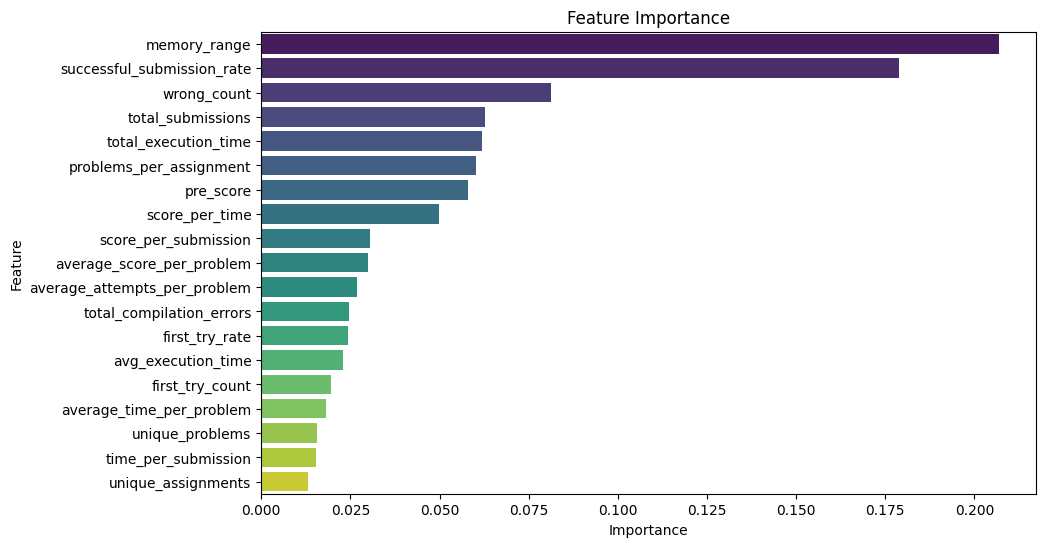

Dự đoán đã được lưu vào file predicted_tbtl.csv


C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\3139070035.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_data['TBTL'] = best_model.predict(X_unlabeled).round(2)


In [15]:
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Đường dẫn tới file dữ liệu
annonimized_file = 'C:\\Users\\CS114\\ThayAn\\annonimized.csv'
tbtl_file = 'C:\\Users\\CS114\\ThayAn\\tbtl-public.csv'

annonimized_df = pd.read_csv(annonimized_file)
tbtl_df = pd.read_csv(tbtl_file)

# Xử lý dữ liệu từ file annonimized
def process_annonymized_data(df):
    # Đổi tên cột
    if "concat('it001',`problem_id`)" in df.columns:
        df.rename(columns={"concat('it001',`problem_id`)": "problem_id"}, inplace=True)
    if "concat('it001', username)" in df.columns:
        df.rename(columns={"concat('it001', username)": "username"}, inplace=True)
    if "concat('it001',`assignment_id`)" in df.columns:
        df.rename(columns={"concat('it001',`assignment_id`)": "assignment_id"}, inplace=True)

    # Trích xuất thông tin từ cột judgement
    def parse_judgement(judgement):
        try:
            judgement_dict = json.loads(judgement)
            wrong_count = judgement_dict.get("verdicts", {}).get("WRONG", 0)
            times = judgement_dict.get("times", [])
            avg_time = sum(times) / len(times) if times else 0
            memory = judgement_dict.get("mems", [])
            memory_range = max(memory) - min(memory) if memory else 0
            return wrong_count, avg_time, memory_range
        except:
            return 0, 0, 0

    df[['wrong_count', 'avg_execution_time', 'memory_range']] = df['judgement'].apply(
        lambda x: pd.Series(parse_judgement(x))
    )
    df['pre_score'] = df['pre_score'].astype(float)

    # Đếm số lỗi biên dịch của từng username
    compilation_errors = df[df['status'] == "Compilation Error"].groupby('username').size().reset_index(name='total_compilation_errors')

    # Nhóm dữ liệu theo username và tính các đặc trưng
    features = df.groupby('username').agg({
        'problem_id': 'nunique',
        'assignment_id': 'nunique',
        'pre_score': 'mean',
        'wrong_count': 'sum',
        'avg_execution_time': 'mean',
        'memory_range': 'mean',
        'judgement': 'count'
    }).reset_index()

    features.rename(columns={
        'problem_id': 'unique_problems',
        'assignment_id': 'unique_assignments',
        'judgement': 'total_submissions'
    }, inplace=True)

    # Tính tỷ lệ bài nộp đúng lần đầu
    first_try = df[df['is_final'] == 1].groupby(['username', 'problem_id']).head(1).reset_index()
    first_try_count = first_try.groupby('username').size().reset_index(name='first_try_count')
    features = features.merge(first_try_count, on='username', how='left')
    features['first_try_rate'] = features['first_try_count'] / features['total_submissions']

    # Gộp lỗi biên dịch
    features = features.merge(compilation_errors, on='username', how='left')
    features['total_compilation_errors'] = features['total_compilation_errors'].fillna(0)

    # Tạo các đặc trưng mới
    features['problems_per_assignment'] = features['unique_problems'] / features['unique_assignments']
    features['time_per_submission'] = features['avg_execution_time'] / features['total_submissions']
    features['successful_submission_rate'] = (features['total_submissions'] - features['total_compilation_errors']) / (features['total_submissions'] + 1e-6)
    features['average_score_per_problem'] = features['pre_score'] / (features['unique_problems'] + 1e-6)
    features['average_time_per_problem'] = features['avg_execution_time'] / (features['unique_problems'] + 1e-6)
    features['average_attempts_per_problem'] = features['total_submissions'] / (features['unique_problems'] + 1e-6)
    features['score_per_time'] = features['pre_score'] / (features['avg_execution_time'] + 1e-6)
    features['score_per_submission'] = features['pre_score'] / (features['total_submissions'] + 1e-6)
    features['total_execution_time'] = features['avg_execution_time'] * features['total_submissions']

    features.fillna(0, inplace=True)
    return features

# Xử lý dữ liệu
processed_data = process_annonymized_data(annonimized_df)
merged_data = processed_data.merge(tbtl_df, on='username', how='left')

# Hiển thị tầm quan trọng của các đặc trưng
labeled_data = merged_data[merged_data['TBTL'].notna()]
X = labeled_data.drop(columns=['username', 'TBTL'])
y = labeled_data['TBTL']
unlabeled_data = merged_data[merged_data['TBTL'].isna()]

# Huấn luyện và đánh giá mô hình
param_grid = {
    'n_estimators': [3000, 3500, 4000, 4500, 5000],
    'max_depth': [10],
    'min_samples_split': [2],
    'min_samples_leaf': [15]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X, y)
best_params = grid_search.best_params_
print(f"Tìm được tham số tối ưu: {best_params}")

best_model = RandomForestRegressor(**best_params, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score with best parameters: {r2}")
# Kiểm tra với số lượng cây khác nhau
estimators = [3000, 3500, 4000, 4500, 5000]
for n in estimators:
    temp_model = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1,min_samples_split=2,min_samples_leaf=15)
    temp_model.fit(X_train, y_train)
    y_pred = temp_model.predict(X_test)
    temp_r2 = r2_score(y_test, y_pred)
    print(f"R² Score with n_estimators={n}: {temp_r2}")

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.show()

# Dự đoán điểm TBTL cho sinh viên chưa có nhãn
X_unlabeled = unlabeled_data[X.columns]
unlabeled_data['TBTL'] = best_model.predict(X_unlabeled).round(2)
unlabeled_data[['username', 'TBTL']].to_csv('predicted_tbtl.csv', index=False, header=False)
print("Dự đoán đã được lưu vào file predicted_tbtl.csv")


## TH

In [6]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Đường dẫn tới file dữ liệu
annonimized_file = 'C:\\Users\\CS114\\ThayAn\\annonimized.csv'
th_file = 'C:\\Users\\CS114\\ThayAn\\th-public.csv'

# Đọc dữ liệu
annonimized_df = pd.read_csv(annonimized_file)
th_df = pd.read_csv(th_file)

def process_annonymized_data(df):
    # Rename columns if necessary
    if "concat('it001',`problem_id`)" in df.columns:
        df.rename(columns={"concat('it001',`problem_id`)": "problem_id"}, inplace=True)
    if "concat('it001', username)" in df.columns:
        df.rename(columns={"concat('it001', username)": "hash"}, inplace=True)
    if "concat('it001',`assignment_id`)" in df.columns:
        df.rename(columns={"concat('it001',`assignment_id`)": "assignment_id"}, inplace=True)

    def parse_judgement(judgement):
        try:
            judgement_dict = json.loads(judgement)
            wrong_count = judgement_dict.get("verdicts", {}).get("WRONG", 0)
            times = judgement_dict.get("times", [])
            avg_time = sum(times) / len(times) if times else 0
            memory = judgement_dict.get("mems", [])
            memory_range = max(memory) - min(memory) if memory else 0
            return wrong_count, avg_time, memory_range
        except:
            return 0, 0, 0

    # Extract features from judgement
    df[['wrong_count', 'avg_execution_time', 'memory_range']] = df['judgement'].apply(
        lambda x: pd.Series(parse_judgement(x))
    )
    df['pre_score'] = pd.to_numeric(df['pre_score'], errors='coerce').fillna(0)
    df['coefficient'] = pd.to_numeric(df['coefficient'], errors='coerce').fillna(1)

    # Calculate submission score
    df['submission_score'] = df['pre_score'] / (df['coefficient'] + 1e-6)

    # Tổng hợp đặc trưng
    features = df.groupby('hash').agg({
        'problem_id': 'nunique',
        'assignment_id': 'nunique',
        'pre_score': 'mean',
        'submission_score': 'mean',
        'wrong_count': 'sum',
        'avg_execution_time': 'mean',
        'memory_range': 'mean',
        'judgement': 'count'
    }).reset_index()
    
    features.rename(columns={'problem_id': 'unique_problems', 'judgement': 'total_submissions'}, inplace=True)

    first_try = df[df['is_final'] == 1].groupby(['hash', 'problem_id']).head(1).reset_index()
    first_try_count = first_try.groupby('hash').size().reset_index(name='first_try_count')
    features = features.merge(first_try_count, on='hash', how='left')
    features['first_try_rate'] = features['first_try_count'] / features['total_submissions']

    # Gộp lỗi biên dịch
    compilation_errors = df[df['status'] == "Compilation Error"].groupby('hash').size().reset_index(name='total_compilation_errors')
    features = features.merge(compilation_errors, on='hash', how='left')
    features['total_compilation_errors'] = features['total_compilation_errors'].fillna(0)

    # Tính tỷ lệ bài làm đúng
    total_problems = df['problem_id'].nunique()
    correct_problems = df[df['is_final'] == 1].groupby('hash')['problem_id'].nunique().reset_index(name='correct_problems')
    features = features.merge(correct_problems, on='hash', how='left')
    features['correct_problems'] = features['correct_problems'].fillna(0)
    features['correct_problem_rate'] = features['correct_problems'] / total_problems

    # Điền giá trị thiếu cho các đặc trưng còn lại
    features.fillna(0, inplace=True)
    return features

# Xử lý dữ liệu
processed_data = process_annonymized_data(annonimized_df)

# Gộp dữ liệu với TH
merged_data = processed_data.merge(th_df, on='hash', how='left')

# Loại bỏ giá trị thiếu hoặc không hợp lệ trong cột TH
merged_data['TH'] = pd.to_numeric(merged_data['TH'], errors='coerce')  # Chuyển cột TH sang kiểu số, nếu không hợp lệ thì chuyển thành NaN
labeled_data = merged_data.dropna(subset=['TH']) # Loại bỏ các hàng có giá trị thiếu trong cột TH

# Chuẩn bị dữ liệu
X = labeled_data.drop(columns=['hash', 'TH']) # Bỏ cột hash và cột TH
y = labeled_data['TH'].astype(float) # Lấy cột TH

# Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler() # StandardScaler: chuẩn hóa dữ liệu theo phân phối chuẩn
X_scaled = scaler.fit_transform(X) # fit_transform: tính toán và chuẩn hóa dữ liệu

# Tìm tham số tối ưu bằng GridSearchCV
param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_scaled, y)

# Huấn luyện mô hình với tham số tối ưu
best_params = grid_search.best_params_
print(f"Tìm được tham số tối ưu: {best_params}")

best_model = RandomForestRegressor(**best_params, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)

# Đánh giá mô hình
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

# Dự đoán cho sinh viên chưa có điểm TH
existing_hashes = set(th_df['hash'])
unlabeled_data = merged_data[~merged_data['hash'].isin(existing_hashes)]
X_unlabeled = scaler.transform(unlabeled_data[X.columns])
predicted_values = np.round(best_model.predict(X_unlabeled), 2)
# Gán giá trị dự đoán vào cột TH
unlabeled_data['TH'] = predicted_values
# Loại bỏ trùng lặp để đảm bảo mỗi sinh viên chỉ xuất hiện một lần
unique_predictions = unlabeled_data[['hash', 'TH']].drop_duplicates(subset=['hash'])
# Xuất kết quả dự đoán
unique_predictions.to_csv('predicted_th.csv', index=False, header=False)
print("Dự đoán đã được lưu vào file predicted-th.csv")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Tìm được tham số tối ưu: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
R^2 Score: 0.3565529916422233
Dự đoán đã được lưu vào file predicted-th.csv


C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\3820380145.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_data['TH'] = predicted_values


## QT

In [4]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Đường dẫn tới file dữ liệu
annonimized_file = 'C:\\Users\\CS114\\ThayAn\\annonimized.csv'
qt_file = 'C:\\Users\\CS114\\ThayAn\\qt-public.csv'

annonimized_df = pd.read_csv(annonimized_file)
qt_df = pd.read_csv(qt_file)

def process_annonymized_data(df):
    # Rename columns if necessary
    if "concat('it001',`problem_id`)" in df.columns:
        df.rename(columns={"concat('it001',`problem_id`)": "problem_id"}, inplace=True)
    if "concat('it001', username)" in df.columns:
        df.rename(columns={"concat('it001', username)": "hash"}, inplace=True)
    if "concat('it001',`assignment_id`)" in df.columns:
        df.rename(columns={"concat('it001',`assignment_id`)": "assignment_id"}, inplace=True)

    def parse_judgement(judgement):
        try:
            judgement_dict = json.loads(judgement)
            wrong_count = judgement_dict.get("verdicts", {}).get("WRONG", 0)
            times = judgement_dict.get("times", [])
            avg_time = sum(times) / len(times) if times else 0
            time_std = np.std(times) if times else 0  # Độ lệch chuẩn của thời gian chạy
            memory = judgement_dict.get("mems", [])
            memory_range = max(memory) - min(memory) if memory else 0
            return wrong_count, avg_time, time_std, memory_range
        except:
            return 0, 0, 0, 0

    # Extract features from judgement
    df[['wrong_count', 'avg_execution_time', 'std_execution_time', 'memory_range']] = df['judgement'].apply(
        lambda x: pd.Series(parse_judgement(x))
    )
    df['pre_score'] = df['pre_score'].astype(float)
    df['coefficient'] = df['coefficient'].astype(float)

    # Calculate submission score
    df['submission_score'] = df['pre_score'] / (df['coefficient'] + 1e-6)  # Avoid division by zero

    # Tổng số lỗi biên dịch
    compilation_errors = df[df['status'] == "Compilation Error"].groupby('hash').size().reset_index(name='total_compilation_errors')

    # Tổng số `problem_id` khác nhau
    total_problems = df['problem_id'].nunique()

    # Số bài làm đúng (`problem_id`) khác nhau của mỗi sinh viên
    correct_problems = df[df['is_final'] == 1].groupby('hash')['problem_id'].nunique().reset_index(name='correct_problems')

    # Aggregate features grouped by hash
    features = df.groupby('hash').agg({
        'problem_id': 'nunique',  # Number of unique problems
        'assignment_id': 'nunique',  # Number of unique assignments
        'pre_score': 'mean',  # Average pre_score
        'submission_score': 'mean',  # Average submission score
        'wrong_count': 'sum',  # Total wrong counts
        'avg_execution_time': 'mean',  # Average execution time
        'std_execution_time': 'mean',  # Average std execution time
        'memory_range': 'mean',  # Average memory range
        'judgement': 'count'  # Number of submissions (judgement count)
    }).reset_index()

    # Rename columns for clarity
    features.rename(columns={
        'problem_id': 'unique_problems',
        'judgement': 'total_submissions'
    }, inplace=True)

    # Tính tỷ lệ bài nộp đúng lần đầu
    first_try = df[df['is_final'] == 1].groupby(['hash', 'problem_id']).head(1).reset_index()
    first_try_count = first_try.groupby('hash').size().reset_index(name='first_try_count')
    features = features.merge(first_try_count, on='hash', how='left')
    features['first_try_rate'] = features['first_try_count'] / features['total_submissions']

    # Gộp lỗi biên dịch
    features = features.merge(compilation_errors, on='hash', how='left')
    features['total_compilation_errors'] = features['total_compilation_errors'].fillna(0)

    # Gộp số bài làm đúng
    features = features.merge(correct_problems, on='hash', how='left')
    features['correct_problems'] = features['correct_problems'].fillna(0)
    features['correct_problem_rate'] = features['correct_problems'] / total_problems
    features['avg_attempts_per_assignment'] = features['total_submissions'] / (features['unique_problems'] + 1e-6)
    features['successful_submission_rate'] = (features['total_submissions'] - features['total_compilation_errors']) / (features['total_submissions'] + 1e-6)
    features['compilation_error_rate'] = features['total_compilation_errors'] / (features['total_submissions'] + 1e-6)

    features.fillna(0, inplace=True)

    return features

# Xử lý dữ liệu
processed_data = process_annonymized_data(annonimized_df)

# Gộp dữ liệu với QT
merged_data = processed_data.merge(qt_df, on='hash', how='left')

# Loại bỏ giá trị thiếu hoặc không hợp lệ trong cột diemqt
merged_data['diemqt'] = pd.to_numeric(merged_data['diemqt'], errors='coerce')  # Chuyển thành NaN nếu không hợp lệ
labeled_data = merged_data.dropna(subset=['diemqt'])  # Loại bỏ hàng có giá trị NaN trong cột diemqt

# Chuẩn hóa đặc trưng
scaler = StandardScaler()
scaled_features = scaler.fit_transform(labeled_data.drop(columns=['hash', 'diemqt']))
scaled_data = pd.DataFrame(scaled_features, columns=labeled_data.drop(columns=['hash', 'diemqt']).columns)

# Chuẩn bị dữ liệu
X = scaled_data
y = labeled_data['diemqt'].astype(float)

# Tìm tham số tối ưu bằng GridSearchCV
param_grid = {
    'n_estimators': [200],
    'max_depth': [7],
    'min_samples_split': [2],
    'min_samples_leaf': [5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X, y)

# Huấn luyện mô hình với tham số tối ưu
best_params = grid_search.best_params_
print(f"Tìm được tham số tối ưu: {best_params}")

best_model = RandomForestRegressor(**best_params, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)

# Đánh giá mô hình
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score with best parameters: {r2}")

# Lọc dữ liệu để chỉ lấy sinh viên chưa có trong file qt-public
existing_hashes = set(qt_df['hash'])
unlabeled_data = merged_data[~merged_data['hash'].isin(existing_hashes)]
X_unlabeled = scaler.transform(unlabeled_data[labeled_data.drop(columns=['hash', 'diemqt']).columns])

# Dự đoán điểm QT và làm tròn đến 2 chữ số thập phân
predicted_values = best_model.predict(X_unlabeled)
rounded_values = np.round(predicted_values, 2)

# Gán giá trị dự đoán vào cột diemqt
unlabeled_data['diemqt'] = rounded_values

# Xuất kết quả dự đoán
unlabeled_data[['hash', 'diemqt']].to_csv('predicted_qt.csv', index=False, header=False)
print("Dự đoán đã được lưu vào file predicted-qt.csv")
#Tìm được tham số tối ưu: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Tìm được tham số tối ưu: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
R^2 Score with best parameters: 0.17855245640864614
Dự đoán đã được lưu vào file predicted-qt.csv


C:\Users\Dong Hung\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\4205120932.py:164: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_data['diemqt'] = rounded_values


## CK

In [5]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Đường dẫn tới file dữ liệu
annonimized_file = 'C:\\Users\\CS114\\ThayAn\\annonimized.csv'
ck_file = 'C:\\Users\\CS114\\ThayAn\\ck-public.csv'

annonimized_df = pd.read_csv(annonimized_file)
ck_df = pd.read_csv(ck_file)

# Hàm xử lý và tính toán đặc trưng
def process_annonymized_data(df):
    # Rename columns if necessary
    if "concat('it001',`problem_id`)" in df.columns:
        df.rename(columns={"concat('it001',`problem_id`)": "problem_id"}, inplace=True)
    if "concat('it001', username)" in df.columns:
        df.rename(columns={"concat('it001', username)": "hash"}, inplace=True)
    if "concat('it001',`assignment_id`)" in df.columns:
        df.rename(columns={"concat('it001',`assignment_id`)": "assignment_id"}, inplace=True)
    
    # Parse judgement JSON
    def parse_judgement(judgement):
        try:
            judgement_dict = json.loads(judgement)
            wrong_count = judgement_dict.get("verdicts", {}).get("WRONG", 0)
            times = judgement_dict.get("times", [])
            avg_time = sum(times) / len(times) if times else 0
            memory = judgement_dict.get("mems", [])
            memory_range = max(memory) - min(memory) if memory else 0
            return wrong_count, avg_time, memory_range
        except:
            return 0, 0, 0

    # Extract features from judgement
    df[['wrong_count', 'avg_execution_time', 'memory_range']] = df['judgement'].apply(
        lambda x: pd.Series(parse_judgement(x))
    )
    df['pre_score'] = df['pre_score'].astype(float)
    df['coefficient'] = df['coefficient'].astype(float)
    df['submission_score'] = df['pre_score'] / (df['coefficient'] + 1e-6)  # Avoid division by zero
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')
    df['submission_time'] = (df['updated_at'] - df['created_at']).dt.total_seconds()

    # Tổng số lỗi biên dịch
    compilation_errors = df[df['status'] == "Compilation Error"].groupby('hash').size().reset_index(name='total_compilation_errors')

    # Tổng số `problem_id` khác nhau
    total_problems = df['problem_id'].nunique()

    # Số bài làm đúng (`problem_id`) khác nhau của mỗi sinh viên
    correct_problems = df[df['is_final'] == 1].groupby('hash')['problem_id'].nunique().reset_index(name='correct_problems')

    # Aggregate features grouped by hash
    features = df.groupby('hash').agg({
        'problem_id': 'nunique',
        'assignment_id': 'nunique',
        'pre_score': 'mean',
        'submission_score': 'mean',
        'wrong_count': 'sum',
        'avg_execution_time': 'mean',
        'memory_range': 'mean',
        'submission_time': 'mean',
        'judgement': 'count'
    }).reset_index()

    # Rename columns for clarity
    features.rename(columns={
        'problem_id': 'unique_problems',
        'judgement': 'total_submissions'
    }, inplace=True)

    # Tính tỷ lệ bài nộp đúng lần đầu
    first_try = df[df['is_final'] == 1].groupby(['hash', 'problem_id']).head(1).reset_index()
    first_try_count = first_try.groupby('hash').size().reset_index(name='first_try_count')
    features = features.merge(first_try_count, on='hash', how='left')
    features['first_try_rate'] = features['first_try_count'] / features['total_submissions']

    # Gộp lỗi biên dịch
    features = features.merge(compilation_errors, on='hash', how='left')
    features['total_compilation_errors'] = features['total_compilation_errors'].fillna(0)

    # Gộp số bài làm đúng
    features = features.merge(correct_problems, on='hash', how='left')
    features['correct_problems'] = features['correct_problems'].fillna(0)
    features['correct_problem_rate'] = features['correct_problems'] / total_problems

    # Các đặc trưng mới
    features['time_per_submission'] = features['avg_execution_time'] / features['total_submissions']
    features['successful_submission_rate'] = (features['total_submissions'] - features['total_compilation_errors']) / (features['total_submissions'] + 1e-6)
    features['average_score_per_problem'] = features['submission_score'] / (features['unique_problems'] + 1e-6)
    features['average_attempts_per_problem'] = features['total_submissions'] / (features['unique_problems'] + 1e-6)
    features['total_execution_time'] = features['avg_execution_time'] * features['total_submissions']
    features['compilation_error_rate'] = features['total_compilation_errors'] / (features['total_submissions'] + 1e-6)

    # Điền giá trị thiếu
    features.fillna(0, inplace=True)

    return features


# Xử lý dữ liệu
processed_data = process_annonymized_data(annonimized_df)

# Gộp dữ liệu với CK
merged_data = processed_data.merge(ck_df, on='hash', how='left')

# Loại bỏ giá trị thiếu hoặc không hợp lệ trong cột CK
merged_data['CK'] = pd.to_numeric(merged_data['CK'], errors='coerce')  # Chuyển thành NaN nếu không hợp lệ
labeled_data = merged_data.dropna(subset=['CK'])  # Loại bỏ hàng có giá trị NaN trong cột CK

# Chuẩn bị dữ liệu
X = labeled_data.drop(columns=['hash', 'CK'])
y = labeled_data['CK'].astype(float)  # Đảm bảo y là số thực

# Tìm tham số tối ưu bằng GridSearchCV
param_grid = {
    'n_estimators': [200, 500, 700, 1000],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 3, 5, 7],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X, y)

# Huấn luyện mô hình với tham số tối ưu
best_params = grid_search.best_params_
print(f"Tìm được tham số tối ưu: {best_params}")

best_model = RandomForestRegressor(**best_params, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)

# Đánh giá mô hình
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score with best parameters: {r2}")

# Làm tròn theo quy tắc tùy chỉnh
def custom_round(value):
    if value % 1 < 0.25:
        return np.floor(value)
    elif value % 1 < 0.75:
        return np.floor(value) + 0.5
    else:
        return np.ceil(value)

existing_hashes = set(ck_df['hash'])

# Lọc dữ liệu để chỉ lấy sinh viên chưa có trong file ck-public
unlabeled_data = merged_data[~merged_data['hash'].isin(existing_hashes)]

# Lọc dữ liệu để dự đoán
X_unlabeled = unlabeled_data[X.columns]

# Dự đoán điểm CK
predicted_values = best_model.predict(X_unlabeled)

# Làm tròn giá trị dự đoán
rounded_values = np.array([custom_round(val) for val in predicted_values])

# Gán giá trị dự đoán vào cột CK
unlabeled_data['CK'] = rounded_values

# Loại bỏ trùng lặp để đảm bảo mỗi sinh viên chỉ xuất hiện một lần
unique_predictions = unlabeled_data[['hash', 'CK']].drop_duplicates(subset=['hash'])

# Xuất kết quả dự đoán
unique_predictions.to_csv('predicted_ck.csv', index=False, header=False)
print("Dự đoán đã được lưu vào file predicted-ck.csv")
# Tìm được tham số tối ưu: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}

C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\2714476485.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\2714476485.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')


Fitting 5 folds for each of 192 candidates, totalling 960 fits


C:\Users\Dong Hung\AppData\Roaming\Python\Python39\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Tìm được tham số tối ưu: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
R^2 Score with best parameters: 0.2841819451650486
Dự đoán đã được lưu vào file predicted-ck.csv


C:\Users\Dong Hung\AppData\Local\Temp\ipykernel_6704\2714476485.py:179: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_data['CK'] = rounded_values
